## Summary

This notebook applies a Variational Autoencoder (VAE) to session-wise resting-state functional connectivity (FC) patterns to explore how TMS modulates brain-wide activity.

- FC patterns are derived using the AAL atlas (116 ROIs; some with NaN values), resulting in symmetric FC matrices per session.
- Data includes 48 subjects, each with 7 sessions by default (5 sessions are missing overall).
- A fully connected VAE with ReLU activation is implemented to learn latent representations from flattened FC matrices.
- This version is called **_raw**, as another **_wtd (subject × condition balanced)** setup is included for comparison.

---

## Main findings so far

- The VAE successfully captures **subject-specific FC profiles** in the latent embedding space.
- To evaluate TMS effects, I computed the **Euclidean distance** between the mean embedding of each sham/real session and the subject’s null session mean, then compared sham vs. real. 
- A promising trend emerged: **distance from real TMS to null was greater** than distance from sham to null.

In [13]:
# Auto-Reload for Fast Iteration
%load_ext autoreload
%autoreload 2

# --- Add project root (the dir that contains 'utils/') to sys.path ---
from pathlib import Path
import sys

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "utils").exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT)) # insert project root at the front of the search list
print("Project root:", ROOT)  # sanity check

# Import custom functions from utils package
from utils.models import VAE, CVAE
from utils.train_utils import (
    train_vae,
    loss_function,
    get_latent_mu,
    get_latent_mu_cvae,
    compute_condition_distances
)
from utils.data_utils import (
    load_all_fc_data,
    preprocess_for_torch
)
from utils.utils_plotting import (
    plot_vae_losses,
    plot_latent_embedding_by_condition_and_subject,
    plot_subject_distance_comparison
)
from utils.bootstrap import *   # common imports, DEVICE

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project root: /Users/liuq13/project-nodeap-fmri-cvae


In [6]:
DATA_DIR = (ROOT / "data").resolve()
sub_cond_path     = DATA_DIR / "SubConds.xlsx"
base_nifti_folder = DATA_DIR / "data_FC"
condition_map = {'N': 0, 'S': 1, 'C': 2}

In [7]:
# Load and preprocess
# load aal FC matrix
all_corr_data, all_tms_type, all_subject_id, all_stimloc, all_session = load_all_fc_data(sub_cond_path, base_nifti_folder, mat_filename='conn_matrix.mat')
X_tensor = preprocess_for_torch(all_corr_data)
dataset = TensorDataset(X_tensor)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True) # each batch has 32 samples

[WARN] File not found: /Users/liuq13/project-nodeap-fmri-cvae/data/data_FC/NODEAP_30/S3D2/conn_matrix.mat
[WARN] File not found: /Users/liuq13/project-nodeap-fmri-cvae/data/data_FC/NODEAP_44/S1D1/conn_matrix.mat
[WARN] File not found: /Users/liuq13/project-nodeap-fmri-cvae/data/data_FC/NODEAP_83/S3D1/conn_matrix.mat
[WARN] File not found: /Users/liuq13/project-nodeap-fmri-cvae/data/data_FC/NODEAP_87/D0/conn_matrix.mat
[WARN] File not found: /Users/liuq13/project-nodeap-fmri-cvae/data/data_FC/NODEAP_88/D0/conn_matrix.mat
Columns with NaN: 229 / 6670
Tensor shape after preprocessing: torch.Size([331, 6441])


In [8]:
# Set up model, optimizer, and device
input_dim = X_tensor.shape[1]
latent_dim = 10
model = VAE(input_dim=input_dim, latent_dim=latent_dim)
NUM_EPOCH = 1000
LR = 3e-4
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
total_loss_hist, recon_loss_hist, kld_loss_hist = train_vae(model, dataloader, optimizer, device=DEVICE, epochs=NUM_EPOCH)


===== Epoch 1 =====


Epoch 1/1000: 100%|████████████████████████████████████████████████| 11/11 [00:00<00:00, 88.34it/s]


Epoch 1, Loss: 6759.7264, Recon: 6758.6684, KL: 1.0579

===== Epoch 2 =====


Epoch 2/1000: 100%|███████████████████████████████████████████████| 11/11 [00:00<00:00, 133.01it/s]


Epoch 2, Loss: 6608.0300, Recon: 6604.1693, KL: 3.8607

===== Epoch 3 =====


...

Epoch 998, Loss: 1320.5268, Recon: 1160.3054, KL: 160.2214

===== Epoch 999 =====


Epoch 999/1000: 100%|█████████████████████████████████████████████| 11/11 [00:00<00:00, 138.27it/s]


Epoch 999, Loss: 1321.5844, Recon: 1160.6215, KL: 160.9629

===== Epoch 1000 =====


Epoch 1000/1000: 100%|████████████████████████████████████████████| 11/11 [00:00<00:00, 140.48it/s]

Epoch 1000, Loss: 1319.6666, Recon: 1158.9614, KL: 160.7052


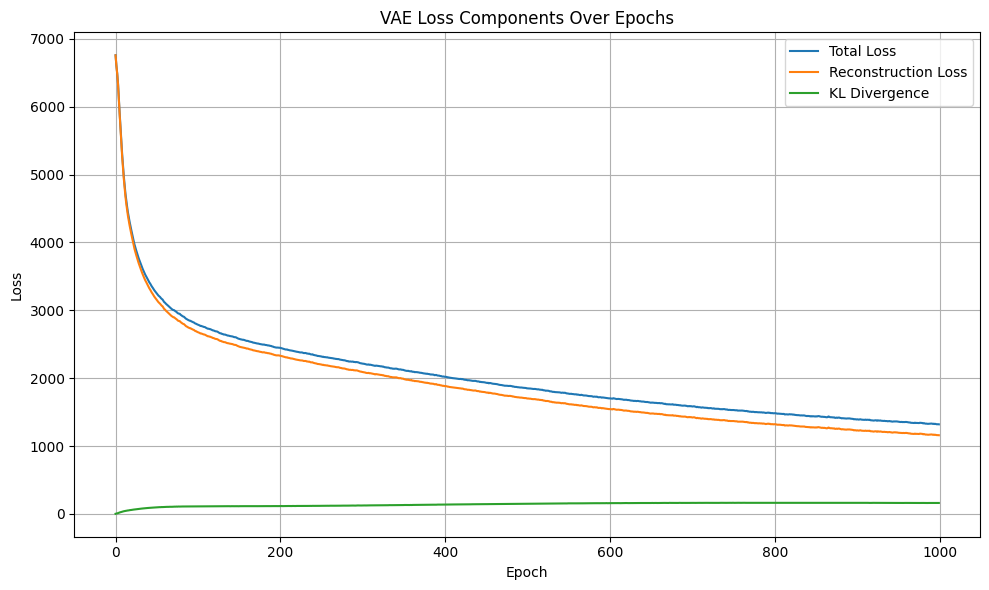

In [9]:
plot_vae_losses(total_loss_hist, recon_loss_hist, kld_loss_hist)

dim of latent mu: (331, 10)


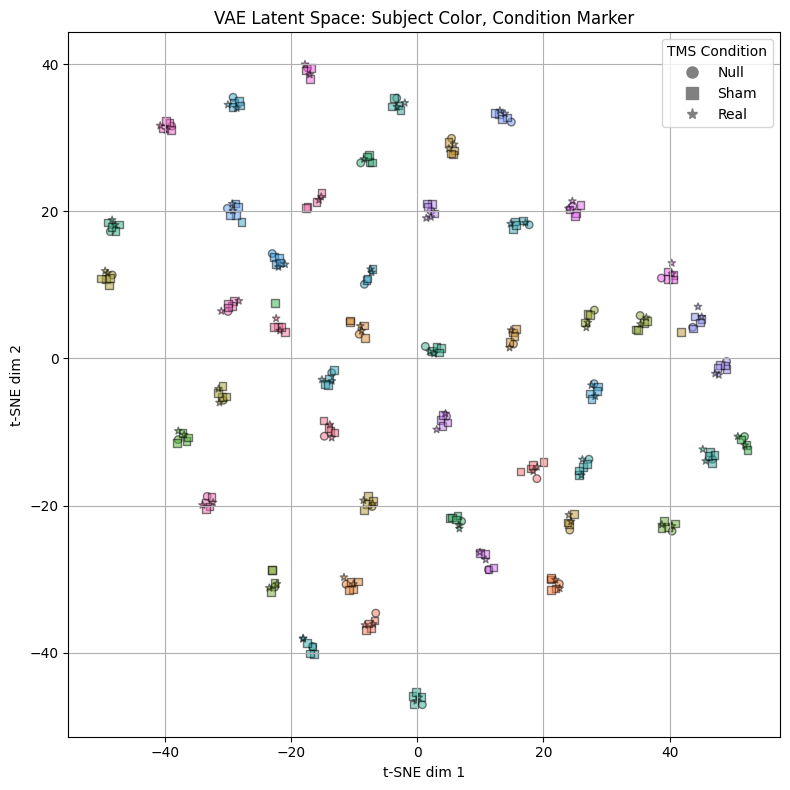

In [11]:
mu_all = get_latent_mu(model, X_tensor, device=DEVICE)

# plot 2d-TSNE
from sklearn.manifold import TSNE
z_2d = TSNE(n_components=2, perplexity=8).fit_transform(mu_all)
plot_latent_embedding_by_condition_and_subject(z_2d, all_tms_type, all_subject_id)

Paired t-test: t = -2.091, p = 0.0422


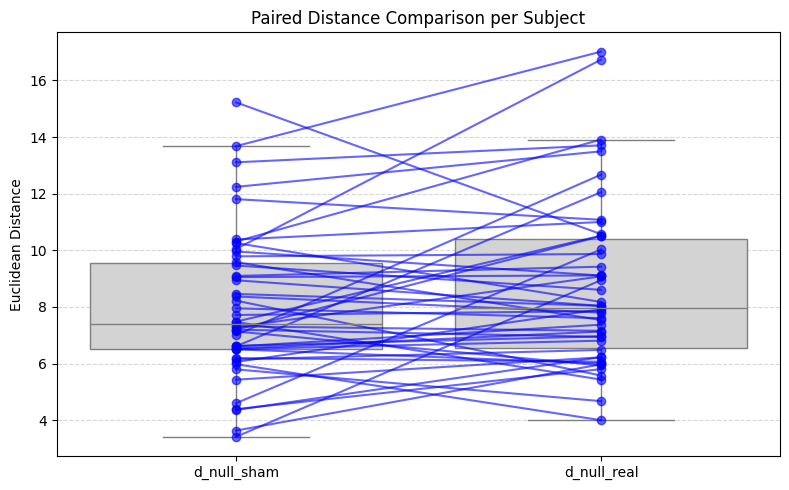

In [12]:
df = compute_condition_distances(mu_all, all_tms_type, all_subject_id, condition_map)

# Paired t-test
t_stat, p_val_t = ttest_rel(df["d_null_sham"], df["d_null_real"])
print(f"Paired t-test: t = {t_stat:.3f}, p = {p_val_t:.4f}")
plot_subject_distance_comparison(df)